# Chapter 14: Indexing


## Core Question

How can an index provide a different access path without changing query results, and what
evidence is needed before recommending one for a workload?

Use this guide with the executable SQL lab cell and `bplus_tree_example.png`.


## Scope and Connection

Chapter 7 improved logical design. An index is a physical structure; it does not repair
update, insertion, or deletion anomalies. Chapters 15 and 16 place indexes inside query
plans and optimizer decisions.

The classroom core is index purpose, B+ tree equality and range access, composite-column
order, covering indexes, and before-and-after query-plan evidence. Dense and sparse
indexes, clustering, splits, and hashing are conceptual extensions.


## Teaching Summary

| Topic | Worked example and practice | Evidence to retain |
|---|---|---|
| Search keys and workload evidence | Customer and date predicates | Query-to-index reason |
| B+ tree access | Equality and range traversal | Visited path and boundary decision |
| Composite and covering indexes | Leading-column and selected-column cases | Supported and unsupported queries |
| Plan verification | Before-and-after SQLite plans | Plan output and bounded conclusion |


## Prerequisites

- Primary, candidate, and foreign keys.
- Selection, range predicates, joins, and `ORDER BY`.
- `CREATE TABLE`, `CREATE INDEX`, and basic aggregate queries.


## Learning Objectives

After completing this chapter, you should be able to:

1. Distinguish a search key from a primary or candidate key.
2. Evaluate an index through access type, expected matches, updates, and storage cost.
3. Trace equality and range access in a simplified B+ tree.
4. Explain the leading-column effect in a composite index.
5. Explain a covering index and its maintenance cost.
6. Use `EXPLAIN QUERY PLAN` to verify an access-path hypothesis.
7. State what the observed plan does and does not prove.


## 1. Index and Search Key

An index is an additional data structure connecting search-key values to records or
record locations. A search key may contain one or more attributes and need not be unique.
A primary key is a logical uniqueness constraint. An index is a physical access path.

For `Enrollment(student_id, course_id, grade)`, the primary key may be
`(student_id, course_id)`. An index on grade supports grade lookup even though many rows
may share the same grade.

### Practice

For `Course(course_id, title, dept_code)`, explain the roles of `course_id` as a primary
key and `dept_code` as an index search key. Department code permits duplicates.


## 2. Workload Evidence

Index evaluation should consider:

- equality, range, prefix, ordering, and join access;
- expected matching rows and access frequency;
- insertion, deletion, and indexed-value update cost;
- index storage;
- the complete workload rather than one isolated query.

### Worked Example

Suppose a registration system performs hundreds of daily lookups for one student's
enrollments and one batch insertion. An index beginning with `student_id` has a plausible
benefit because the frequent equality query retrieves few rows. The claim still requires
row-count and plan evidence.

Compare that workload with one dominated by grade updates and very few grade lookups.
The second case may not justify a grade index because maintenance is frequent and lookup
benefit is rare.


## 3. B+ Tree Access

A B+ tree is a balanced ordered index. Internal nodes contain separator keys and child
pointers. Leaves contain search-key entries and record references, and adjacent leaves
are linked in order. Every root-to-leaf path has the same length.

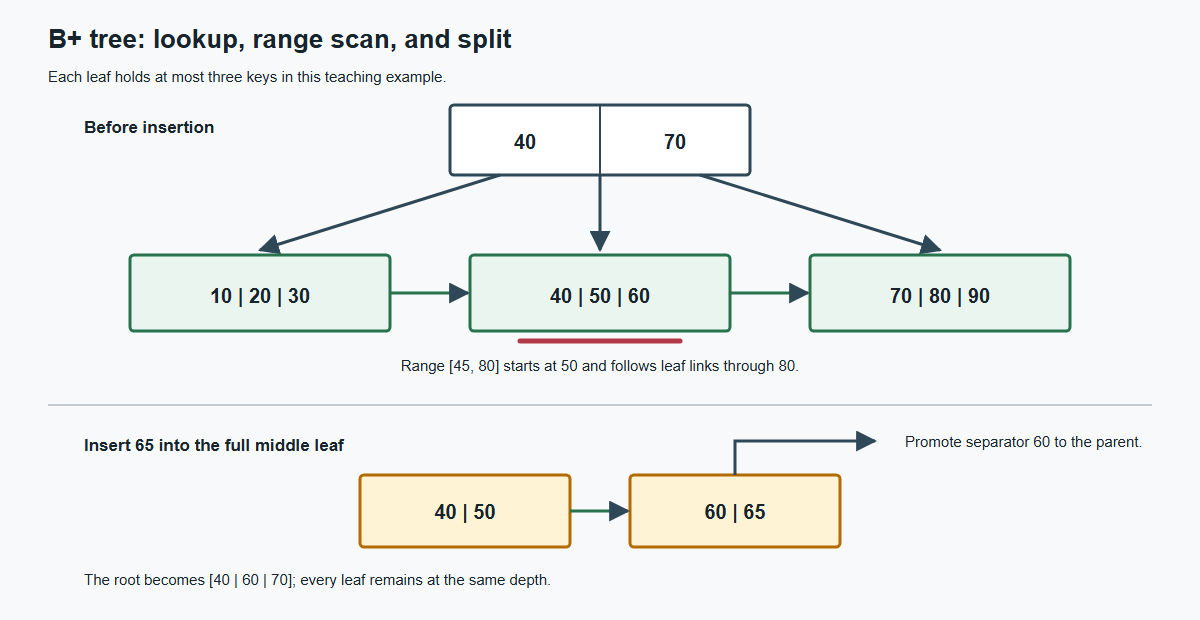

The figure is a teaching abstraction, not a claim about SQLite's private page format.

### Equality Lookup

To find 50:

1. Compare 50 with root separators 40 and 70.
2. Follow the middle child for `40 <= key < 70`.
3. Find 50 in the leaf and follow its record reference.

### Range Lookup

For `45 <= key <= 80`, descend once to the first qualifying leaf, output 50 and 60, follow
the leaf link to 70 and 80, and stop at 90. Linked ordered leaves avoid restarting from
the root for every value.

### Predict and Check

Trace keys 25, 65, and 100. For range `[25,75]`, the output is 30, 40, 50, 60, and 70;
encountering 80 establishes the stop condition.


## 4. Composite Indexes

A composite index `(A, B)` is ordered first by A and then by B within equal A values. It
normally supports `A = value` and `A = value AND B range` efficiently. A predicate on B
alone does not provide the same leading ordered range.

```sql
SELECT ordered_at, amount
FROM ch14_order_line
WHERE customer_id = 'C0042'
  AND ordered_at BETWEEN '2026-01-01' AND '2026-12-31'
ORDER BY ordered_at;
```

`(customer_id, ordered_at)` groups one customer's rows and orders them by date. Reversing
the columns primarily groups all rows by date.

### Practice

For `(dept_code, salary)`, reason about:

```text
A. dept_code = 'IM'
B. dept_code = 'IM' AND salary BETWEEN 50000 AND 70000
C. salary = 60000
D. dept_code < 'IM' AND salary = 60000
```

A uses the first component. B uses equality on the first and a range on the second. C
lacks the leading component. In D, the first component is already a range, so the second
does not form one simple continuous search interval. An actual DBMS may have additional
techniques, so inspect the plan.


## 5. Covering Index

An index covers a query when it contains every column required for filtering and output,
allowing the DBMS to avoid a separate table lookup.

The lab first uses `(customer_id, ordered_at)`. The query also returns amount, so a table
lookup may remain. After adding amount, SQLite 3.45.3 reports a covering index for the
supplied query.

Adding columns increases index size, reduces fanout, and increases write cost. If the
report also returns status, the existing index no longer covers it. Do not add status
before considering report frequency and update workload.


## 6. Query-Plan Lab

The lab creates 20,000 reproducible rows and observes:

1. a scan without a secondary index;
2. an index search using `(customer_id, ordered_at)`;
3. a covering search after amount is included;
4. plans for a missing leading predicate and a low-selectivity status predicate.

```sql
CREATE INDEX idx_name ON table_name (column1, column2);
DROP INDEX idx_name;
EXPLAIN QUERY PLAN SELECT ...;
```

Before each phase, predict `SCAN` or `SEARCH`, the useful predicate, and whether the index
covers the output. Then retain:

- the complete plan;
- the index name;
- displayed predicate bounds;
- the query result;
- SQLite version and statistics state.

In the verified environment, the first phase scans, the composite-index phase searches
by customer and date, and the final phase reports a covering index. A plan difference in
another version is evidence to investigate, not text to overwrite.

The high-frequency status `COMPLETE` matches most rows. Even if a status index exists, the
optimizer may reasonably prefer a scan.


## Conceptual Extensions

- **Clustering index:** record order follows the search-key order.
- **Secondary index:** index order differs from record order.
- **Dense index:** has an entry for every search-key value.
- **Sparse index:** has entries for selected values and requires compatible record order.
- **B+ tree split:** an overflowing node divides and sends a separator upward while all
  leaves remain at one depth.
- **Hash index:** can support equality lookup but does not retain key order for a range.

Complete B+ tree insertion/deletion algorithms and cost derivations are not classroom
core requirements.


## Common Errors

1. Assuming that a search key is unique.
2. Claiming that an index changes query results or repairs normalization.
3. Indexing every column without considering writes and storage.
4. Ignoring composite-column order.
5. Comparing one timing without checking plans and cache conditions.
6. Treating successful `CREATE INDEX` as proof that a query used the index.
7. Treating the textbook B+ tree drawing as a DBMS page-layout specification.


## Classroom and Individual Evidence

Propose at most two indexes for three supplied queries. State the query-to-index reason,
unsupported query, and write/storage cost. Compare plans after the proposal is fixed.

Retain the original proposal, three plans, revised proposal, and one statement that the
current evidence cannot support. Peer ranking does not directly determine the grade.


## Chapter Summary

Index selection starts from workload evidence. B+ trees support ordered equality and
range access, composite order controls useful leading predicates, and covering can avoid
a table lookup at additional maintenance cost. Chapter 15 places these access paths in a
complete query-processing plan.


## After-Class Continuation

Inspect one additional query plan before and after creating a justified index. Retain the
query, index definition, both plans, and a brief statement about the write or storage cost
that the plan output does not measure.


## Build and Inspect the Chapter Database

The executable cells use SQLite through Python's standard `sqlite3` module. Follow the
cells in order:

1. Open a database connection and enable foreign-key enforcement.
2. Execute the chapter's `CREATE TABLE` statements before inserting rows.
3. Load the synthetic example data.
4. Inspect the resulting tables, columns, primary keys, and foreign keys.
5. Check referential integrity before running the chapter queries.
6. Predict each query result, execute it, and explain any difference.

`DATABASE_NAME` is initially `:memory:`. The database disappears when its connection
closes; closing a browser tab alone may leave the kernel and connection running.
Change it to a filename such as `chapter_database.db` when you want SQLite to create a
persistent database in the notebook's working directory. Do not switch to a persistent
file until the in-memory version runs successfully from top to bottom.


In [1]:
import sqlite3

print(f"Python {__import__('sys').version.split()[0]}; SQLite {sqlite3.sqlite_version}")
DATABASE_NAME = ":memory:"  # Change to "chapter_database.db" to keep a database file.
connection = sqlite3.connect(DATABASE_NAME, isolation_level=None)
connection.execute("PRAGMA foreign_keys = ON")


def run_sql_script(connection, script, max_rows=20):
    """Execute a SQLite script and display result-producing statements."""
    buffer = ""
    for raw_line in script.splitlines():
        stripped = raw_line.strip()
        if stripped.startswith(".print"):
            message = stripped[len(".print"):].strip().strip("\"'")
            print(f"\n{message}")
            continue
        buffer += raw_line + "\n"
        if not sqlite3.complete_statement(buffer):
            continue
        statement = buffer.strip()
        buffer = ""
        if not statement:
            continue
        cursor = connection.execute(statement)
        if cursor.description:
            columns = [column[0] for column in cursor.description]
            rows = cursor.fetchmany(max_rows + 1)
            print(" | ".join(columns))
            for row in rows[:max_rows]:
                print(" | ".join("NULL" if value is None else str(value) for value in row))
            if len(rows) > max_rows:
                print(f"... additional rows omitted after {max_rows}")
    remaining = "\n".join(
        line for line in buffer.splitlines() if not line.strip().startswith("--")
    ).strip()
    if remaining:
        raise ValueError("The embedded SQL ends with an incomplete statement.")


def inspect_database(connection):
    """Display tables, columns, primary keys, foreign keys, and integrity status."""
    tables = [
        row[0]
        for row in connection.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name"
        )
    ]
    print("Tables:", ", ".join(tables) if tables else "none")
    for table in tables:
        columns = connection.execute(f'PRAGMA table_info("{table}")').fetchall()
        primary_key = [row[1] for row in sorted(columns, key=lambda row: row[5]) if row[5]]
        print(f"\n{table}")
        print("  columns:", ", ".join(f"{row[1]} {row[2]}" for row in columns))
        print("  primary key:", ", ".join(primary_key) if primary_key else "none")
        for index_row in connection.execute(f'PRAGMA index_list("{table}")').fetchall():
            if index_row[2] and index_row[3] == "u":
                unique_columns = [
                    row[2]
                    for row in connection.execute(
                        f'PRAGMA index_info("{index_row[1]}")'
                    ).fetchall()
                ]
                print("  unique constraint:", ", ".join(unique_columns))
        foreign_keys = connection.execute(f'PRAGMA foreign_key_list("{table}")').fetchall()
        for foreign_key in foreign_keys:
            print(f"  foreign key: {foreign_key[3]} -> {foreign_key[2]}.{foreign_key[4]}")
    violations = connection.execute("PRAGMA foreign_key_check").fetchall()
    print("\nForeign-key check:", "PASS" if not violations else violations)


Python 3.12.9; SQLite 3.45.3


### Index and query-plan lab


In [2]:
SQL_1 = """PRAGMA foreign_keys = ON;

-- === PHASE 1: SETUP ===
DROP INDEX IF EXISTS ch14_idx_customer_date;
DROP INDEX IF EXISTS ch14_idx_customer_date_amount;
DROP TABLE IF EXISTS ch14_order_line;

CREATE TABLE ch14_order_line (
    line_id     INTEGER PRIMARY KEY,
    customer_id TEXT NOT NULL,
    ordered_at  TEXT NOT NULL,
    status      TEXT NOT NULL CHECK (status IN ('COMPLETE', 'PENDING', 'CANCELLED')),
    amount      NUMERIC NOT NULL CHECK (amount >= 0)
);

WITH RECURSIVE seq(n) AS (
    VALUES (1)
    UNION ALL
    SELECT n + 1 FROM seq WHERE n < 20000
)
INSERT INTO ch14_order_line(line_id, customer_id, ordered_at, status, amount)
SELECT n,
       printf('C%04d', ((n * 37) % 1000) + 1),
       date('2026-01-01', printf('+%d days', (n * 13) % 365)),
       CASE
           WHEN n % 10 < 8 THEN 'COMPLETE'
           WHEN n % 10 = 8 THEN 'PENDING'
           ELSE 'CANCELLED'
       END,
       round(50 + ((n * 17) % 5000) / 10.0, 2)
FROM seq;

ANALYZE;

SELECT COUNT(*) AS total_rows,
       COUNT(DISTINCT customer_id) AS customers
FROM ch14_order_line;

EXPLAIN QUERY PLAN
SELECT ordered_at, amount
FROM ch14_order_line
WHERE customer_id = 'C0042'
  AND ordered_at BETWEEN '2026-01-01' AND '2026-12-31'
ORDER BY ordered_at;

-- === PHASE 2: COMPOSITE INDEX ===
CREATE INDEX ch14_idx_customer_date
ON ch14_order_line(customer_id, ordered_at);
ANALYZE;

EXPLAIN QUERY PLAN
SELECT ordered_at, amount
FROM ch14_order_line
WHERE customer_id = 'C0042'
  AND ordered_at BETWEEN '2026-01-01' AND '2026-12-31'
ORDER BY ordered_at;

SELECT ordered_at, amount
FROM ch14_order_line
WHERE customer_id = 'C0042'
  AND ordered_at BETWEEN '2026-01-01' AND '2026-12-31'
ORDER BY ordered_at;

-- The leading customer_id predicate is absent. Record the actual plan; do not assume
-- that every DBMS/version handles this query in the same way.
EXPLAIN QUERY PLAN
SELECT COUNT(*)
FROM ch14_order_line
WHERE ordered_at BETWEEN '2026-06-01' AND '2026-06-30';

-- === PHASE 3: COVERING INDEX ===
CREATE INDEX ch14_idx_customer_date_amount
ON ch14_order_line(customer_id, ordered_at, amount);
ANALYZE;

EXPLAIN QUERY PLAN
SELECT ordered_at, amount
FROM ch14_order_line
WHERE customer_id = 'C0042'
  AND ordered_at BETWEEN '2026-01-01' AND '2026-12-31'
ORDER BY ordered_at;

-- COMPLETE matches most rows. A scan can be reasonable when a predicate is not
-- selective and the query needs a large part of the table.
EXPLAIN QUERY PLAN
SELECT line_id, customer_id, ordered_at, status, amount
FROM ch14_order_line
WHERE status = 'COMPLETE';

-- The covering index has the same leading columns as the smaller composite index.
-- Remove the redundant teaching-stage index after comparing the two plans.
DROP INDEX ch14_idx_customer_date;
"""


In [3]:
run_sql_script(connection, SQL_1)


total_rows | customers
20000 | 1000
id | parent | notused | detail
3 | 0 | 0 | SCAN ch14_order_line
15 | 0 | 0 | USE TEMP B-TREE FOR ORDER BY
id | parent | notused | detail
4 | 0 | 0 | SEARCH ch14_order_line USING INDEX ch14_idx_customer_date (customer_id=? AND ordered_at>? AND ordered_at<?)
ordered_at | amount
2026-01-15 | 468.1
2026-01-20 | 68.1
2026-02-14 | 468.1
2026-03-16 | 468.1
2026-04-10 | 368.1
2026-04-15 | 468.1
2026-05-10 | 368.1
2026-06-04 | 268.1
2026-06-09 | 368.1
2026-07-04 | 268.1
2026-07-09 | 368.1
2026-08-03 | 268.1
2026-08-28 | 168.1
2026-09-02 | 268.1
2026-09-27 | 168.1
2026-10-22 | 68.1
2026-10-27 | 168.1
2026-11-21 | 68.1
2026-11-26 | 168.1
2026-12-21 | 68.1
id | parent | notused | detail
3 | 0 | 0 | SEARCH ch14_order_line USING COVERING INDEX ch14_idx_customer_date (ANY(customer_id) AND ordered_at>? AND ordered_at<?)
id | parent | notused | detail
3 | 0 | 0 | SEARCH ch14_order_line USING COVERING INDEX ch14_idx_customer_date_amount (customer_id=? AND ordered_at>?

### Inspect the Database You Created

Read the output as a schema check: confirm the table names, column types, primary-key order, foreign-key direction, and integrity result.


In [4]:
inspect_database(connection)


Tables: ch14_order_line

ch14_order_line
  columns: line_id INTEGER, customer_id TEXT, ordered_at TEXT, status TEXT, amount NUMERIC
  primary key: line_id

Foreign-key check: PASS


### Reproducibility Check


In [5]:
assert connection.execute("SELECT COUNT(*) FROM ch14_order_line").fetchone()[0] == 20000
assert connection.execute("SELECT COUNT(*) FROM ch14_order_line WHERE status='COMPLETE'").fetchone()[0] == 16000
print("Notebook checks passed.")


Notebook checks passed.


In [6]:
connection.close()
print("Database connection closed.")


Database connection closed.
